In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries Imported Successfully")

Libraries Imported Successfully


# Adidas Sales Analysis Dashboard

## 📌 Project Overview
This project analyzes Adidas US sales data using Python and Jupyter Notebook.

## 🎯 Objectives
- Analyze revenue trends
- Identify profitable products
- Perform regional analysis
- Create business insights

In [18]:
df = pd.read_excel(r"C:\Users\Hp\Desktop\Projects\GitHub Projects\Adidas Sales Analysis\Data\Adidas US Sales Datasets.xlsx")

df.head()

,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin,Sales Method
0,Foot Locker,1185732,2020-01-01,Northeast,New York,New York,Men's Street Footwear,50.0,1200,600000.0,300000.0,0.50,In-store
1,Foot Locker,1185732,2020-01-02,Northeast,New York,New York,Men's Athletic Footwear,50.0,1000,500000.0,150000.0,0.30,In-store
2,Foot Locker,1185732,2020-01-03,Northeast,New York,New York,Women's Street Footwear,40.0,1000,400000.0,140000.0,0.35,In-store
3,Foot Locker,1185732,2020-01-04,Northeast,New York,New York,Women's Athletic Footwear,45.0,850,382500.0,133875.0,0.35,In-store
4,Foot Locker,1185732,2020-01-05,Northeast,New York,New York,Men's Apparel,60.0,900,540000.0,162000.0,0.30,In-store


In [19]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nInfo:")
df.info()

Shape: (9648, 13)

Columns:
Index(['Retailer', 'Retailer ID', 'Invoice Date', 'Region', 'State', 'City',
       'Product', 'Price per Unit', 'Units Sold', 'Total Sales',
       'Operating Profit', 'Operating Margin', 'Sales Method'],
      dtype='str')

Info:
<class 'pandas.DataFrame'>
RangeIndex: 9648 entries, 0 to 9647
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Retailer          9648 non-null   str           
 1   Retailer ID       9648 non-null   int64         
 2   Invoice Date      9648 non-null   datetime64[us]
 3   Region            9648 non-null   str           
 4   State             9648 non-null   str           
 5   City              9648 non-null   str           
 6   Product           9648 non-null   str           
 7   Price per Unit    9648 non-null   float64       
 8   Units Sold        9648 non-null   int64         
 9   Total Sales       9648 non-null   float64    

In [20]:
df.isnull().sum()

Retailer            0
Retailer ID         0
Invoice Date        0
Region              0
State               0
City                0
Product             0
Price per Unit      0
Units Sold          0
Total Sales         0
Operating Profit    0
Operating Margin    0
Sales Method        0
dtype: int64

In [21]:
# Remove duplicates
df = df.drop_duplicates()

# Convert date column
df['Invoice Date'] = pd.to_datetime(df['Invoice Date'])

print("Data Cleaning Completed")

Data Cleaning Completed


In [22]:
df['Year'] = df['Invoice Date'].dt.year
df['Month'] = df['Invoice Date'].dt.month_name()
df['Quarter'] = df['Invoice Date'].dt.quarter

df.head()

,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin,Sales Method,Year,Month,Quarter
0,Foot Locker,1185732,2020-01-01,Northeast,New York,New York,Men's Street Footwear,50.0,1200,600000.0,300000.0,0.50,In-store,2020,January,1
1,Foot Locker,1185732,2020-01-02,Northeast,New York,New York,Men's Athletic Footwear,50.0,1000,500000.0,150000.0,0.30,In-store,2020,January,1
2,Foot Locker,1185732,2020-01-03,Northeast,New York,New York,Women's Street Footwear,40.0,1000,400000.0,140000.0,0.35,In-store,2020,January,1
3,Foot Locker,1185732,2020-01-04,Northeast,New York,New York,Women's Athletic Footwear,45.0,850,382500.0,133875.0,0.35,In-store,2020,January,1
4,Foot Locker,1185732,2020-01-05,Northeast,New York,New York,Men's Apparel,60.0,900,540000.0,162000.0,0.30,In-store,2020,January,1


In [23]:
total_revenue = df['Total Sales'].sum()
total_profit = df['Operating Profit'].sum()
total_units = df['Units Sold'].sum()
avg_price = df['Price per Unit'].mean()

profit_margin = (total_profit / total_revenue) * 100

print("Total Revenue:", total_revenue)
print("Total Profit:", total_profit)
print("Total Units Sold:", total_units)
print("Average Price:", avg_price)
print("Profit Margin %:", profit_margin)

Total Revenue: 899902125.0
Total Profit: 332134761.45
Total Units Sold: 2478861
Average Price: 45.21662520729685
Profit Margin %: 36.90787611486082


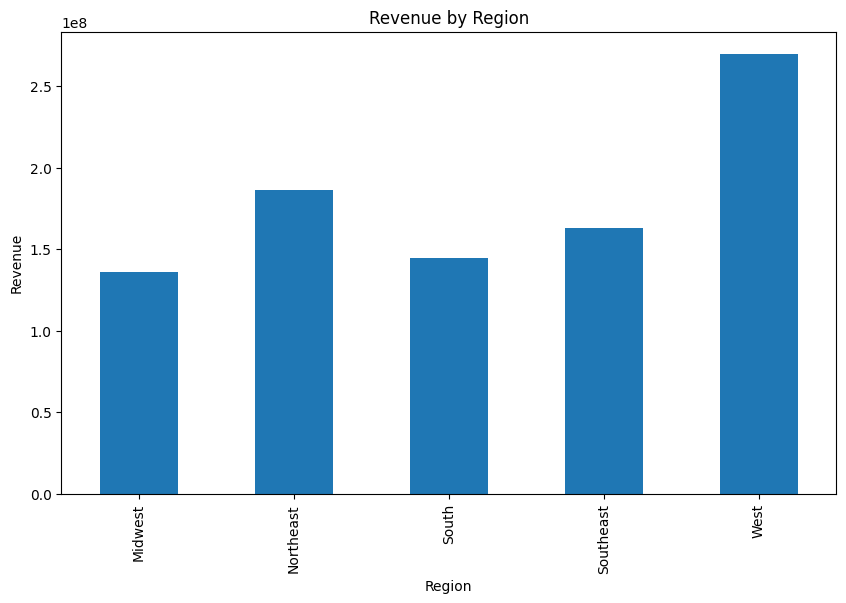

In [24]:
region_sales = df.groupby('Region')['Total Sales'].sum()

plt.figure(figsize=(10,6))
region_sales.plot(kind='bar')

plt.title('Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Revenue')

plt.show()

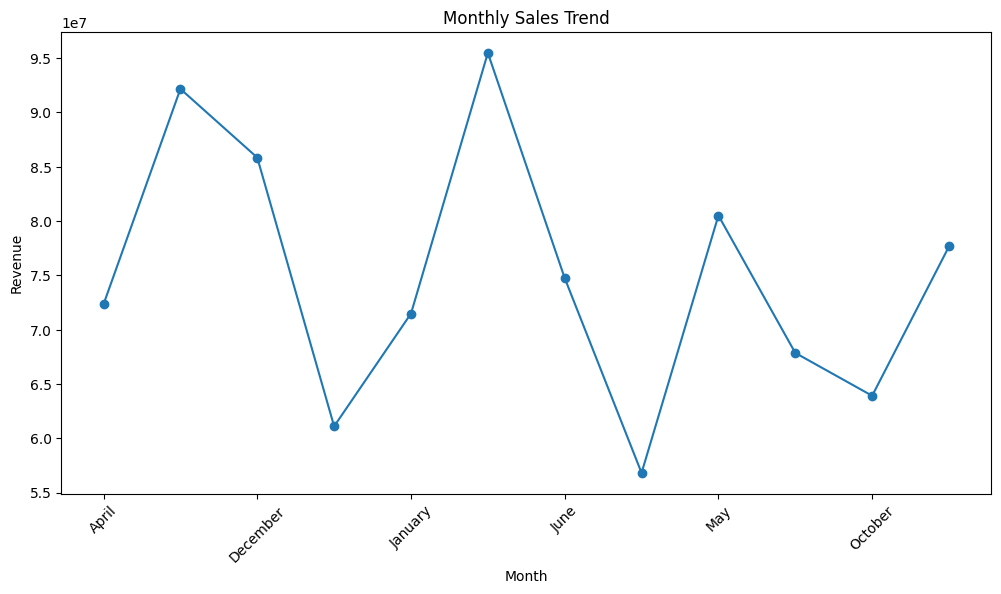

In [25]:
monthly_sales = df.groupby('Month')['Total Sales'].sum()

plt.figure(figsize=(12,6))
monthly_sales.plot(marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.xticks(rotation=45)

plt.show()

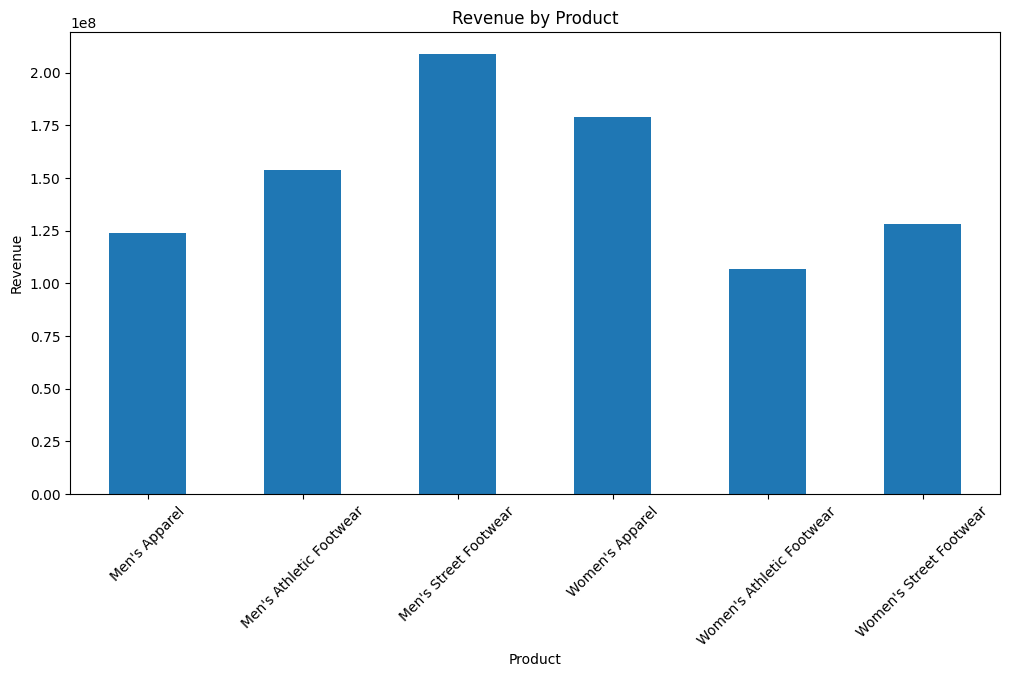

In [26]:
product_sales = df.groupby('Product')['Total Sales'].sum()

plt.figure(figsize=(12,6))
product_sales.plot(kind='bar')

plt.title('Revenue by Product')
plt.xlabel('Product')
plt.ylabel('Revenue')

plt.xticks(rotation=45)

plt.show()

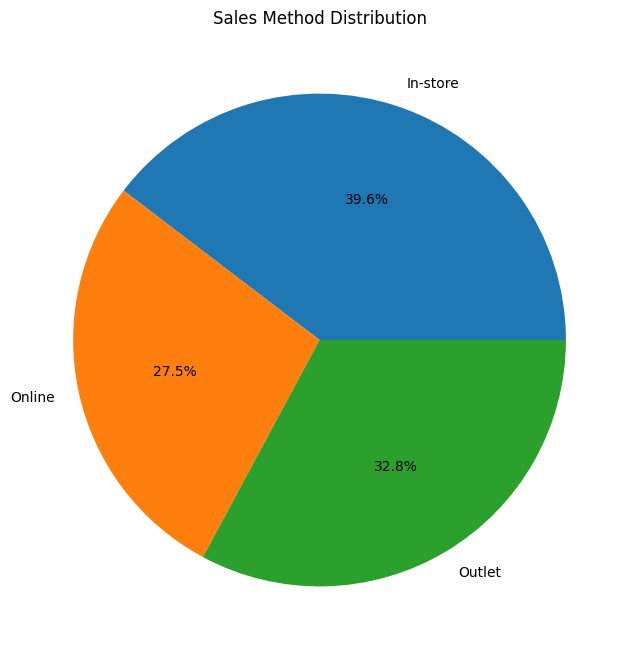

In [27]:
sales_method = df.groupby('Sales Method')['Total Sales'].sum()

plt.figure(figsize=(8,8))
sales_method.plot(kind='pie', autopct='%1.1f%%')

plt.title('Sales Method Distribution')
plt.ylabel('')

plt.show()

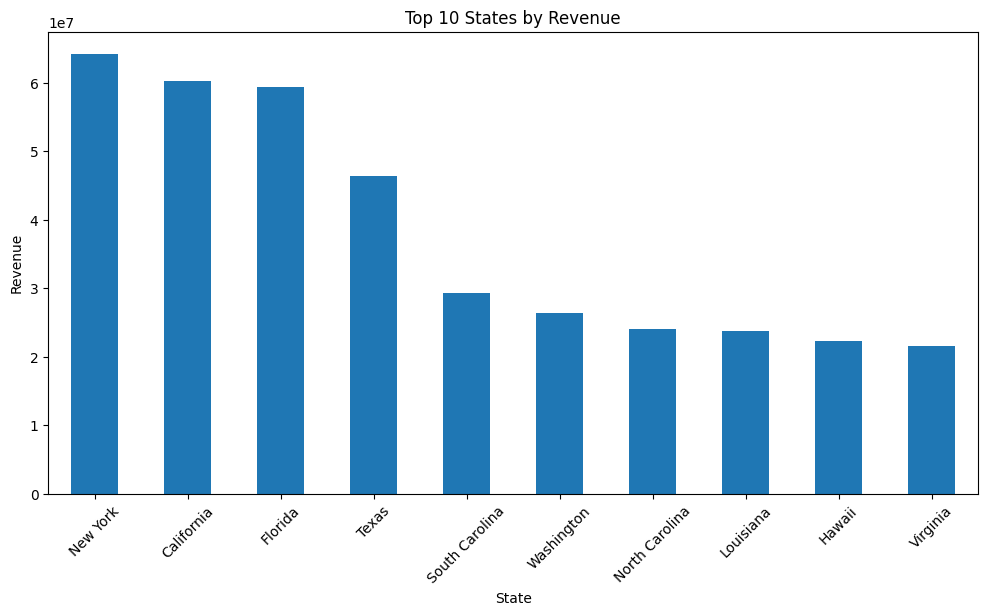

In [28]:
top_states = df.groupby('State')['Total Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top_states.plot(kind='bar')

plt.title('Top 10 States by Revenue')
plt.xlabel('State')
plt.ylabel('Revenue')

plt.xticks(rotation=45)

plt.show()

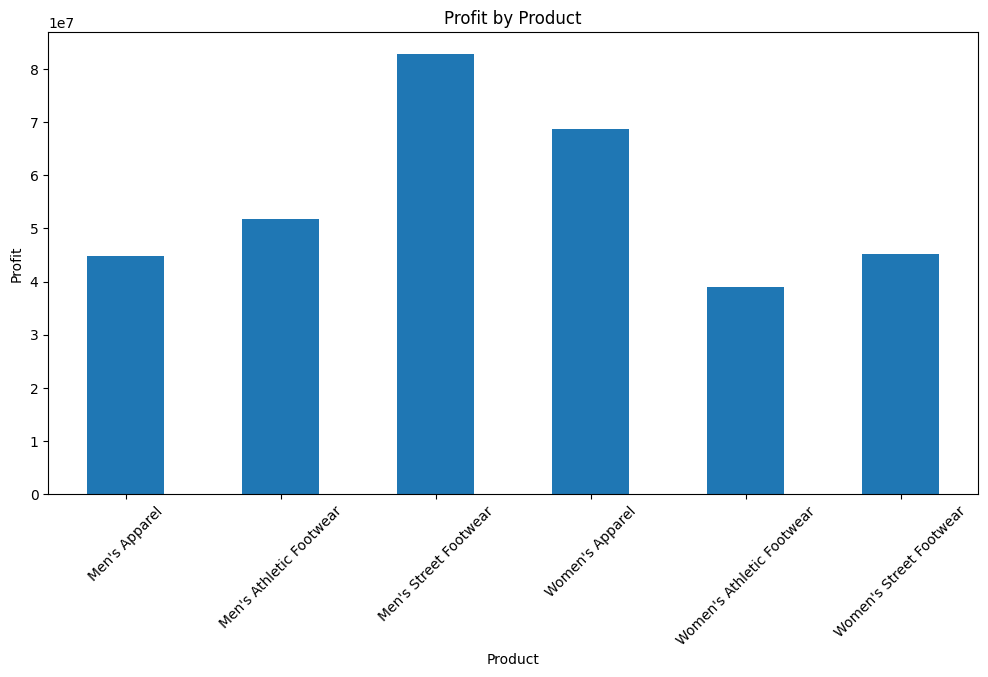

In [29]:
profit_analysis = df.groupby('Product')['Operating Profit'].sum()

plt.figure(figsize=(12,6))
profit_analysis.plot(kind='bar')

plt.title('Profit by Product')
plt.xlabel('Product')
plt.ylabel('Profit')

plt.xticks(rotation=45)

plt.show()

## 💡 Key Insights

- West region generated the highest revenue
- Men’s Street Footwear was the top-performing product
- In-store sales contributed maximum revenue

## ✅ Conclusion

The Adidas Sales Analysis dashboard transformed raw sales data into an interactive business intelligence solution that supports strategic decision-making.